半正規分布

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from IPython.display import display
import seaborn as sns
np.set_printoptions(precision=3, floatmode='fixed')
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", None)

import pymc as pm
import arviz as az

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on ArviZ v{az.__version__}")

Running on PyMC v5.27.0
Running on ArviZ v0.23.0


In [2]:
sigma = 1.0

model10 = pm.Model()
with model10:
    x = pm.HalfNormal('x', sigma=sigma) # 非負

with model10:
    prior_samples10 = pm.sample_prior_predictive(random_seed=42)

x_samples10 = prior_samples10['prior']['x'].values
print(x_samples10[:,:100])

Sampling: [x]


[[0.418 0.606 0.029 1.084 1.464 0.291 1.331 0.035 0.280 0.107 1.921 1.579
  1.006 0.451 0.593 0.094 1.852 0.256 0.283 0.416 1.089 1.967 0.887 1.328
  0.132 0.362 0.782 0.283 1.006 0.019 1.243 2.603 0.151 0.516 0.220 0.402
  1.361 0.743 0.937 0.175 1.525 0.098 1.165 0.524 1.066 0.311 0.556 0.100
  0.258 1.590 1.815 0.536 1.271 0.554 1.724 0.312 0.063 1.382 0.585 0.510
  0.251 0.406 0.866 0.534 0.039 1.143 0.464 2.267 0.529 0.325 0.154 0.820
  1.203 0.095 1.362 0.277 0.307 1.404 1.539 1.597 1.268 0.744 1.379 0.373
  0.225 0.797 0.190 0.405 1.567 1.622 0.559 1.285 0.649 0.642 2.170 0.549
  0.032 0.744 1.306 0.870]]


In [3]:
value_counts10 = pd.DataFrame(x_samples10.reshape(-1)).value_counts().sort_index()
print(value_counts10)

0    
0.007    1
0.012    1
0.013    1
0.017    1
0.019    1
        ..
2.458    1
2.528    1
2.603    1
2.844    1
4.093    1
Name: count, Length: 500, dtype: int64


In [4]:
# サンプリング結果の分析
summary10 = az.summary(prior_samples10, kind='stats')
display(summary10)

,mean,sd,hdi_3%,hdi_97%
x,0.760,0.591,0.007,1.777


Text(0.5, 1.0, '半正規分布 sigma=1.0')

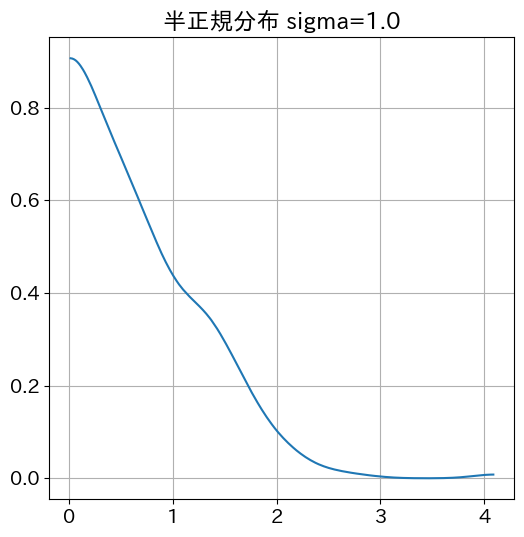

In [5]:
ax = az.plot_dist(x_samples10) # 値がい浮動小数点の場合は自動で連続分布からサンプリングしたものと判断して連続関数で近似する
ax.set_title(f"半正規分布 sigma={sigma}")